/var/folders/vb/9lm3mj5n1_573j4kn1bw4fnc0000gn/T/ipykernel_63246/2750242660.py:120: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/Users/viktorzozula/Documents/Cats-in-Pain-Bachelors/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


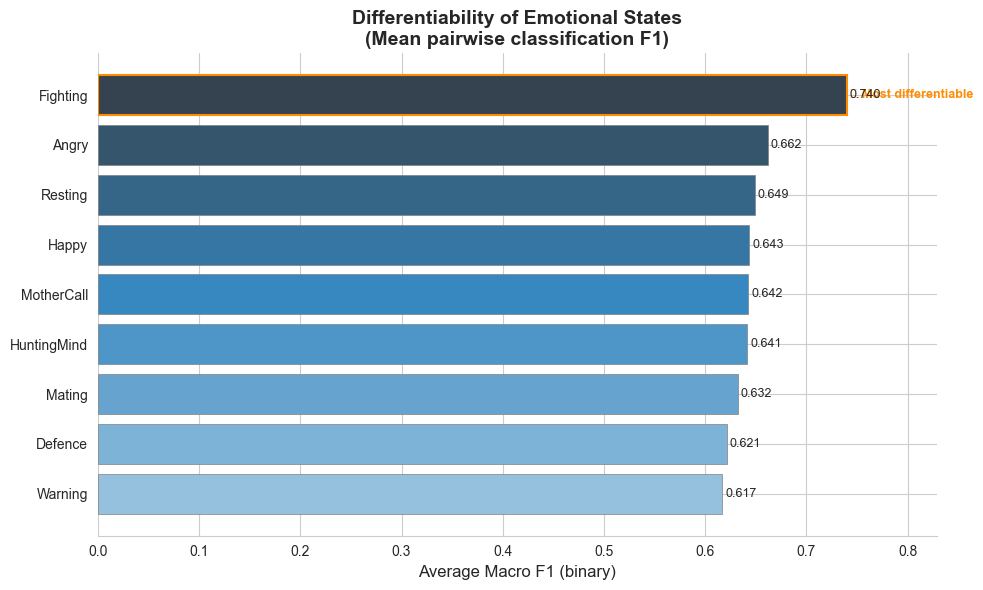

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------------------------
# 1. Hardcoded data from your table (pair, val_macro_f1_binary)
# --------------------------------------------------------------------
data = [
    ("Fighting,Resting", 0.794368),
    ("Fighting,HuntingMind", 0.784367),
    ("Fighting,Warning", 0.777778),
    ("Fighting,MotherCall", 0.768729),
    ("Defence,Fighting", 0.756672),
    ("Happy,Resting", 0.721568),
    ("Defence,Warning", 0.721362),
    ("Angry,Mating", 0.710790),
    ("Fighting,Mating", 0.698147),
    ("Angry,MotherCall", 0.691734),
    ("Happy,MotherCall", 0.688261),
    ("Angry,Fighting", 0.684481),
    ("Angry,Resting", 0.683024),
    ("Happy,Warning", 0.659120),
    ("Fighting,Happy", 0.655738),
    ("Happy,HuntingMind", 0.651482),
    ("Mating,MotherCall", 0.646629),
    ("Happy,Mating", 0.646166),
    ("Angry,Warning", 0.638009),
    ("MotherCall,Resting", 0.636977),
    ("Defence,Mating", 0.636774),
    ("Defence,Resting", 0.635569),
    ("Angry,Happy", 0.633807),
    ("HuntingMind,MotherCall", 0.627363),
    ("HuntingMind,Resting", 0.626772),
    ("Angry,Defence", 0.625616),
    ("Angry,HuntingMind", 0.625241),
    ("HuntingMind,Mating", 0.623153),
    ("Defence,HuntingMind", 0.615385),
    ("Mating,Resting", 0.609356),
    ("MotherCall,Warning", 0.591543),
    ("HuntingMind,Warning", 0.576714),
    ("Defence,Happy", 0.490625),
    ("Defence,MotherCall", 0.488000),
    ("Mating,Warning", 0.485714),
    ("Resting,Warning", 0.484330),
]

# --------------------------------------------------------------------
# 2. Build DataFrame and extract emotion names
# --------------------------------------------------------------------
df = pd.DataFrame(data, columns=["pair", "f1"])
# Split the pair into two emotions
emotions = df["pair"].str.split(",", expand=True)
# Stack all emotion columns to get one row per emotion occurrence
all_emotions = pd.concat([emotions[0], emotions[1]], ignore_index=True)
# Attach the F1 score (each pair contributes its F1 twice, once per emotion)
f1_stacked = pd.concat([df["f1"], df["f1"]], ignore_index=True)
# Average F1 per emotion
avg_f1 = f1_stacked.groupby(all_emotions).mean().sort_values(ascending=False)

# --------------------------------------------------------------------
# 3. Create a polished bar chart
# --------------------------------------------------------------------
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

# Use a color gradient: darkest colour for the top emotion (Fighting)
palette = sns.color_palette("Blues_d", n_colors=len(avg_f1))
# Reverse so highest value gets darkest shade
palette = palette[::-1]

bars = ax.barh(
    avg_f1.index,          # emotions on y-axis (horizontal bars)
    avg_f1.values,
    color=palette,
    edgecolor="grey",
    linewidth=0.5,
)

# Highlight "Fighting" by making its bar slightly thicker or adding a star
for bar, emotion in zip(bars, avg_f1.index):
    if emotion == "Fighting":
        bar.set_edgecolor("darkorange")
        bar.set_linewidth(1.5)
        ax.text(
            bar.get_width() + 0.002,
            bar.get_y() + bar.get_height() / 2,
            "★ Most differentiable",
            va="center",
            fontsize=9,
            color="darkorange",
            fontweight="bold",
        )

# Labels and title
ax.set_xlabel("Average Macro F1 (binary)", fontsize=12)
ax.set_title(
    "Differentiability of Emotional States\n(Mean pairwise classification F1)",
    fontsize=14,
    fontweight="bold",
)

# Add value labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.003,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=9,
    )

# Make sure the highest value bar doesn't touch the right spine
ax.set_xlim(0, avg_f1.max() * 1.12)

# Invert y-axis so the highest value is at the top
ax.invert_yaxis()

sns.despine(left=True)  # remove the redundant left spine
plt.tight_layout()
plt.show()